![IITIS](pictures/logoIITISduze.png)

In [159]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

def calculate_energy_ising(J: np.ndarray, h: np.ndarray, state):
    state = state.T
    return state @ J @ state.T + state @ h 


def simulated_bifurcation(J, h, time, time_step, M, trajectories):
    # Ustawianie parametrów
    K = 1
    delta = 0.5 # delta = 1
    small_delta_t = time_step/M
    N = len(h)
    sigma = np.std(J.flatten())
    #xi_0 = 0.7 * time_step / sigma * sqrt(N)
    xi_0 = 0.1
    num_steps = int(time / time_step)
    
   

    # Iniclizacja
    # x = np.random.uniform(-0.1, 0.1, (N, trajectories))
    x = np.zeros((N, trajectories))
    #y = np.random.uniform(-0.1, 0.1, (N, trajectories))
    y = np.array([[0], [0.1]])
    p = np.linspace(0, 2, num=num_steps + 1)

    x_1_history = []
    y_1_history = []
    timeline = np.array([t*time_step for t in range(num_steps + 1)])

    for p_t in p:
        x += delta * y * time_step
        y -= (K * np.power(x, 3) + (delta - p_t) * x - xi_0 * J @ x) * time_step
        x_1_history.append(x[0, 0])
        y_1_history.append(y[0, 0])
        # x_m = x
        # y_m = y

        # for _ in range(M):
        #     x_m += delta * y_m * small_delta_t
        #     y_m -= (np.power(x_m, 2) + (delta - p_t) * x_m) * small_delta_t

        # x = x_m
        # y = y_m + xi_0 * J @ x * time_step
        

    
    plt.plot(timeline, x_1_history)
    plt.plot(timeline, y_1_history)
    plt.ylim(-1.5, 1.5)
    plt.legend(["x_1", "y_1"])
    plt.ylabel("t")
    plt.show()
    solution = np.sign(x)
    return solution, -0.5 * solution.T @ J @ solution

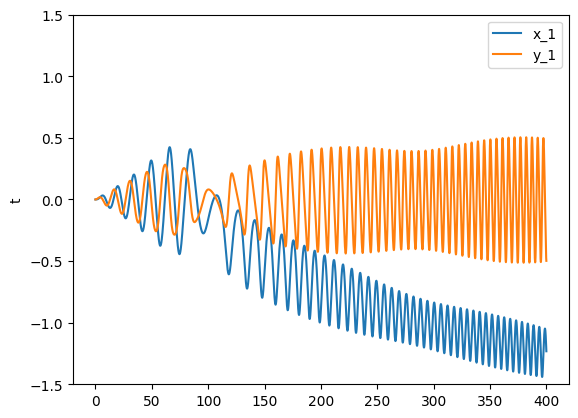

(array([[-1.],
        [-1.]]),
 array([[-0.5]]))

In [163]:
n = 2


# J = np.triu(np.random.uniform(-1, 1, (n, n))) # losowa gęsta macierz górnotrójkątna
# np.fill_diagonal(J, 0.0)

J = np.triu(np.ones((n, n)))
np.fill_diagonal(J, 0.0)
h = np.zeros(n)
# from dimod import BinaryQuadraticModel
# from dwave.samplers import SimulatedAnnealingSampler

# bqm_instance = BinaryQuadraticModel(h, J, vartype="SPIN")
# sampler= SimulatedAnnealingSampler()
# sampleset = sampler.sample(bqm_instance, num_reads=1)
# print(sampleset)

time = 400
time_step = 0.001
M = 2

simulated_bifurcation(J, h, time, time_step, M, 1)
